In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats

# Hardcoded slice of your exact uploaded dataset
raw_data = [
    ["Low", 3.518, 2.293, "Micro", 55.261],
    ["Low", 7.756, 2.572, "Mega", 67.574],
    ["High", 20.348, 1.227, "Micro", 272.250],
    ["Medium", 20.108, 2.728, "Mega", 195.102],
    ["High", 31.653, 7.776, "Nano", 273.960],
    ["Low", 5.561, 3.530, "Nano", 39.992],
    ["Medium", 13.951, 4.477, "Micro", 147.150],
    ["Medium", 28.352, 4.695, "Mega", 229.141],
    ["Medium", 15.322, 4.379, "Macro", 222.696],
    ["High", 26.914, 6.074, "Mega", 322.466]
]

df = pd.DataFrame(raw_data, columns=['TV', 'Radio', 'Social Media', 'Influencer', 'Sales'])
print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
       TV   Radio  Social Media Influencer    Sales
0     Low   3.518         2.293      Micro   55.261
1     Low   7.756         2.572       Mega   67.574
2    High  20.348         1.227      Micro  272.250
3  Medium  20.108         2.728       Mega  195.102
4    High  31.653         7.776       Nano  273.960


In [4]:
# Convert categorical strings to dummy indicator variables
df_encoded = pd.get_dummies(df, columns=['TV', 'Influencer'], drop_first=True, dtype=int)

# Set up variables for the regression model
X = df_encoded.drop(columns=['Sales'])
X = sm.add_constant(X)
y = df_encoded['Sales']

# Fit and print the Linear Regression Model
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.968
Method:                 Least Squares   F-statistic:                     40.36
Date:                Fri, 12 Jun 2026   Prob (F-statistic):             0.0244
Time:                        02:18:14   Log-Likelihood:                -34.977
No. Observations:                  10   AIC:                             85.95
Df Residuals:                       2   BIC:                             88.37
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              268.3615     51.411  

ValueError: normal is not a valid distribution name

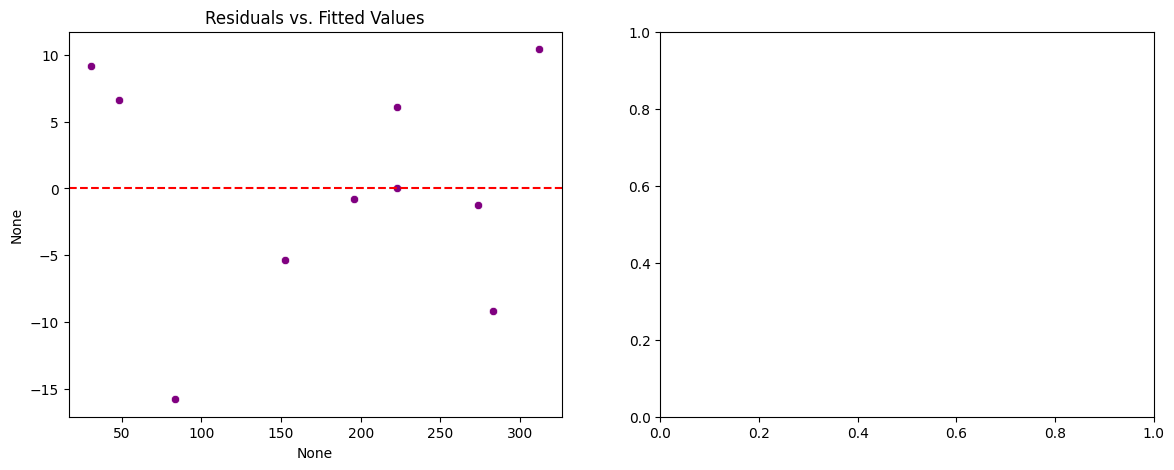

In [5]:
# Plot residual diagnostics to check regression assumptions
residuals = model.resid
fitted = model.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=fitted, y=residuals, ax=axes[0], color='purple')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Residuals vs. Fitted Values')

stats.probplot(residuals, dist="normal", plot=axes[1])
axes[1].set_title('Normal Q-Q Plot')
plt.show()